<a href="https://colab.research.google.com/github/Kaushhki/NeuroScan--BrainMRI_Project/blob/main/Neuroscan.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')

import os
project_dir = "/content/drive/MyDrive/brain_mri_project"
os.makedirs(project_dir, exist_ok=True)

Mounted at /content/drive


In [2]:
from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"kaushhkimishra","key":"0750d8dda35cb31648396fd42ff217cb"}'}

In [3]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json
!pip install -q kaggle

!kaggle datasets download -d ninadaithal/imagesoasis
!unzip -q -n imagesoasis.zip -d oasis_data

!kaggle datasets download -d jboysen/mri-and-alzheimers
!unzip -q -n mri-and-alzheimers.zip -d demo_data

Dataset URL: https://www.kaggle.com/datasets/ninadaithal/imagesoasis
License(s): apache-2.0
100% 1.23G/1.23G [01:11<00:00, 18.5MB/s]

Dataset URL: https://www.kaggle.com/datasets/jboysen/mri-and-alzheimers
License(s): CC0-1.0
100% 12.6k/12.6k [00:00<00:00, 39.0MB/s]



In [4]:
import os, re, json
import pandas as pd
import numpy as np
from sklearn.model_selection import GroupShuffleSplit

demo = pd.read_csv("demo_data/oasis_cross-sectional.csv")

base = "oasis_data/Data"
classes_found = [c for c in os.listdir(base) if os.path.isdir(os.path.join(base, c))]

rows = []
for cls in classes_found:
    folder = os.path.join(base, cls)
    for fname in os.listdir(folder):
        match = re.match(r'(OAS1_\d+_MR1)', fname)
        if match:
            rows.append({"path": os.path.join(folder, fname), "class": cls, "ID": match.group(1)})

img_df = pd.DataFrame(rows)
full_df = img_df.merge(demo[['ID', 'Age']], on='ID', how='inner')

def merge_classes(cls):
    if cls in ["Mild Dementia", "Moderate Dementia"]:
        return "Mild-to-Moderate Dementia"
    return cls

full_df['class'] = full_df['class'].apply(merge_classes)

gss1 = GroupShuffleSplit(n_splits=1, test_size=0.3, random_state=42)
train_idx, temp_idx = next(gss1.split(full_df, groups=full_df['ID']))
train_df = full_df.iloc[train_idx].copy()
temp_df = full_df.iloc[temp_idx].copy()

gss2 = GroupShuffleSplit(n_splits=1, test_size=0.5, random_state=42)
val_idx, test_idx = next(gss2.split(temp_df, groups=temp_df['ID']))
val_df = temp_df.iloc[val_idx].copy()
test_df = temp_df.iloc[test_idx].copy()

classes = sorted(full_df['class'].unique())
class_to_idx = {c: i for i, c in enumerate(classes)}
age_mean = train_df['Age'].mean()
age_std = train_df['Age'].std()

for df in [train_df, val_df, test_df]:
    df['class_idx'] = df['class'].map(class_to_idx)
    df['age_norm'] = (df['Age'] - age_mean) / age_std

assert len(set(train_df['ID']) & set(val_df['ID'])) == 0
assert len(set(train_df['ID']) & set(test_df['ID'])) == 0
assert len(set(val_df['ID']) & set(test_df['ID'])) == 0

train_df.to_csv(f"{project_dir}/train_df.csv", index=False)
val_df.to_csv(f"{project_dir}/val_df.csv", index=False)
test_df.to_csv(f"{project_dir}/test_df.csv", index=False)

with open(f"{project_dir}/meta.json", "w") as f:
    json.dump({"age_mean": age_mean, "age_std": age_std, "class_to_idx": class_to_idx}, f)

print("Class mapping:", class_to_idx)
print("Train:", len(train_df), "Val:", len(val_df), "Test:", len(test_df))

Class mapping: {'Mild-to-Moderate Dementia': 0, 'Non Demented': 1, 'Very mild Dementia': 2}
Train: 56974 Val: 12322 Test: 12505


In [5]:
import tensorflow as tf

IMG_SIZE = 128
NUM_CLASSES = len(classes)

def load_and_preprocess(path, class_idx, age_norm):
    img = tf.io.read_file(path)
    img = tf.image.decode_jpeg(img, channels=1)
    img = tf.image.resize(img, [IMG_SIZE, IMG_SIZE])
    img = img / 255.0
    class_onehot = tf.one_hot(class_idx, NUM_CLASSES)
    return img, {"disease_output": class_onehot, "age_output": age_norm}

def make_dataset(df, shuffle=False, batch_size=32, shuffle_buffer=8000):
    paths = df['path'].values
    class_idx = df['class_idx'].values.astype('int32')
    age_norm = df['age_norm'].values.astype('float32')
    ds = tf.data.Dataset.from_tensor_slices((paths, class_idx, age_norm))
    if shuffle:
        ds = ds.shuffle(buffer_size=shuffle_buffer)
    ds = ds.map(load_and_preprocess, num_parallel_calls=tf.data.AUTOTUNE)
    return ds.batch(batch_size).prefetch(tf.data.AUTOTUNE)

def make_class_dataset(df, class_idx_value, batch_size, shuffle_buffer=4000):
    class_df = df[df['class_idx'] == class_idx_value]
    paths = class_df['path'].values
    class_idx = class_df['class_idx'].values.astype('int32')
    age_norm = class_df['age_norm'].values.astype('float32')
    ds = tf.data.Dataset.from_tensor_slices((paths, class_idx, age_norm))
    ds = ds.shuffle(shuffle_buffer).repeat()
    ds = ds.map(load_and_preprocess, num_parallel_calls=tf.data.AUTOTUNE)
    return ds

per_class_batch = 32 // NUM_CLASSES
class_datasets = [make_class_dataset(train_df, i, per_class_batch) for i in range(NUM_CLASSES)]
train_ds_balanced = tf.data.Dataset.sample_from_datasets(class_datasets, weights=[1/NUM_CLASSES]*NUM_CLASSES)
train_ds_balanced = train_ds_balanced.batch(32).prefetch(tf.data.AUTOTUNE)
steps_per_epoch = len(train_df) // 32

val_ds = make_dataset(val_df)
test_ds = make_dataset(test_df)

print("Pipelines ready. steps_per_epoch =", steps_per_epoch)

Pipelines ready. steps_per_epoch = 1780


In [6]:
from tensorflow.keras import layers, models

def build_model(img_size=128, n_classes=3):
    inputs = layers.Input(shape=(img_size, img_size, 1))

    x = layers.Conv2D(32, 3, activation='relu', padding='same')(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D()(x)

    x = layers.Conv2D(64, 3, activation='relu', padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D()(x)

    x = layers.Conv2D(128, 3, activation='relu', padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D()(x)

    x = layers.Conv2D(256, 3, activation='relu', padding='same')(x)
    x = layers.GlobalAveragePooling2D()(x)

    shared = layers.Dense(128, activation='relu')(x)
    shared = layers.Dropout(0.4)(shared)

    disease_branch = layers.Dense(64, activation='relu')(shared)
    disease_output = layers.Dense(n_classes, activation='softmax', name='disease_output')(disease_branch)

    age_branch = layers.Dense(64, activation='relu')(shared)
    age_output = layers.Dense(1, activation='linear', name='age_output')(age_branch)

    return models.Model(inputs=inputs, outputs=[disease_output, age_output])

model = build_model(IMG_SIZE, NUM_CLASSES)
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss={"disease_output": "categorical_crossentropy", "age_output": "mse"},
    loss_weights={"disease_output": 1.0, "age_output": 0.3},
    metrics={"disease_output": "accuracy", "age_output": "mae"}
)
print("Model built and compiled")

Model built and compiled


In [7]:
callbacks = [
    tf.keras.callbacks.ModelCheckpoint(
        filepath=os.path.join(project_dir, "best_model_final.keras"),
        save_best_only=True, monitor="val_loss", verbose=1
    ),
    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss", patience=8, restore_best_weights=True, verbose=1
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss", factor=0.5, patience=4, verbose=1
    ),
    tf.keras.callbacks.CSVLogger(
        os.path.join(project_dir, "training_log_final.csv")
    )
]

history = model.fit(
    train_ds_balanced,
    validation_data=val_ds,
    steps_per_epoch=steps_per_epoch,
    epochs=30,
    callbacks=callbacks
)

Epoch 1/30
1780/1780 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - age_output_loss: 0.4216 - age_output_mae: 0.4933 - disease_output_accuracy: 0.5966 - disease_output_loss: 0.8253 - loss: 0.9518
Epoch 1: val_loss improved from None to 0.94802, saving model to /content/drive/MyDrive/brain_mri_project/best_model_final.keras

Epoch 1: finished saving model to /content/drive/MyDrive/brain_mri_project/best_model_final.keras
1780/1780 ━━━━━━━━━━━━━━━━━━━━ 65s 30ms/step - age_output_loss: 0.3129 - age_output_mae: 0.4248 - disease_output_accuracy: 0.7085 - disease_output_loss: 0.6548 - loss: 0.7487 - val_age_output_loss: 1.2206 - val_age_output_mae: 0.9343 - val_disease_output_accuracy: 0.8318 - val_disease_output_loss: 0.5800 - val_loss: 0.9480 - learning_rate: 1.0000e-04
Epoch 2/30
1780/1780 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - age_output_loss: 0.2211 - age_output_mae: 0.3620 - disease_output_accuracy: 0.8722 - disease_output_loss: 0.3466 - loss: 0.4129
Epoch 2: val_loss improved from 0.94802 to 0.7830

In [8]:
from sklearn.metrics import classification_report, confusion_matrix, mean_absolute_error
import numpy as np

preds = model.predict(test_ds)
disease_preds = np.argmax(preds[0], axis=1)
true_classes = test_df['class_idx'].values

print(classification_report(true_classes, disease_preds, target_names=classes))
print("Confusion matrix:")
print(confusion_matrix(true_classes, disease_preds))

age_preds_years = preds[1].flatten() * age_std + age_mean
true_ages = test_df['Age'].values
mae_years = mean_absolute_error(true_ages, age_preds_years)
print(f"\nAge MAE (in actual years): {mae_years:.2f}")

391/391 ━━━━━━━━━━━━━━━━━━━━ 14s 32ms/step
                           precision    recall  f1-score   support

Mild-to-Moderate Dementia       0.16      0.18      0.17       488
             Non Demented       0.88      0.85      0.87      9821
       Very mild Dementia       0.48      0.53      0.50      2196

                 accuracy                           0.77     12505
                macro avg       0.51      0.52      0.51     12505
             weighted avg       0.78      0.77      0.77     12505

Confusion matrix:
[[  88  289  111]
 [ 283 8371 1167]
 [ 169  865 1162]]

Age MAE (in actual years): 10.50


In [9]:
import tensorflow as tf
import json

project_dir = "/content/drive/MyDrive/brain_mri_project"

model = tf.keras.models.load_model(f"{project_dir}/best_model_final.keras")

with open(f"{project_dir}/meta.json") as f:
    meta = json.load(f)

age_mean = meta["age_mean"]
age_std = meta["age_std"]
class_to_idx = meta["class_to_idx"]
idx_to_class = {v: k for k, v in class_to_idx.items()}

IMG_SIZE = 128
print("Model loaded. Classes:", idx_to_class)

Model loaded. Classes: {0: 'Mild-to-Moderate Dementia', 1: 'Non Demented', 2: 'Very mild Dementia'}


True label: Non Demented | True age: 80
Path: oasis_data/Data/Non Demented/OAS1_0033_MR1_mpr-2_122.jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step


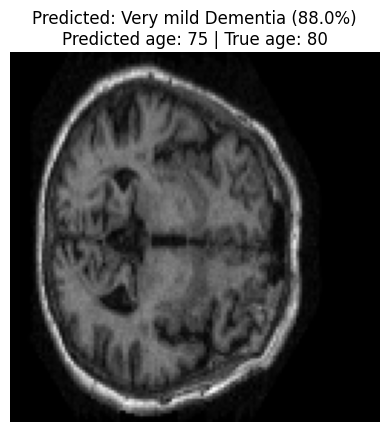


--- Full breakdown ---
Mild-to-Moderate Dementia: 0.1%
Non Demented: 11.9%
Very mild Dementia: 88.0%
True class: Non Demented | Predicted class: Very mild Dementia
True age: 80 | Predicted age: 75.0


In [22]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

# Grab a random image from the TEST set (one the model never saw during training)
sample_row = test_df.sample(1).iloc[0]
img_path = sample_row['path']
true_class = sample_row['class']
true_age = sample_row['Age']

print("True label:", true_class, "| True age:", true_age)
print("Path:", img_path)

# Preprocess exactly like training
img = tf.io.read_file(img_path)
img = tf.image.decode_jpeg(img, channels=1)
img = tf.image.resize(img, [IMG_SIZE, IMG_SIZE])
img_display = img.numpy().astype("uint8").squeeze()
img = img / 255.0
img_batch = tf.expand_dims(img, axis=0)

disease_pred, age_pred = model.predict(img_batch)
predicted_class = idx_to_class[np.argmax(disease_pred)]
confidence = np.max(disease_pred) * 100
predicted_age = age_pred[0][0] * age_std + age_mean

plt.imshow(img_display, cmap='gray')
plt.axis('off')
plt.title(f"Predicted: {predicted_class} ({confidence:.1f}%)\nPredicted age: {predicted_age:.0f} | True age: {true_age}")
plt.show()

print("\n--- Full breakdown ---")
for i, prob in enumerate(disease_pred[0]):
    print(f"{idx_to_class[i]}: {prob*100:.1f}%")
print(f"True class: {true_class} | Predicted class: {predicted_class}")
print(f"True age: {true_age} | Predicted age: {predicted_age:.1f}")

In [23]:
!pip install -q gradio

In [24]:
from google.colab import files
uploaded = files.upload()  # pick your NEUROSCAN logo PNG
logo_path = list(uploaded.keys())[0]

Saving watermarked_img_4797055739447254155.png to watermarked_img_4797055739447254155.png


In [37]:
import gradio as gr
import numpy as np
import tensorflow as tf
from PIL import Image

# NeuroScan brand palette (soft terracotta + dusty teal, inspired by your reference)
custom_theme = gr.themes.Soft(
    primary_hue=gr.themes.Color(c50="#f7ece7", c100="#f0d9d0", c200="#e2b8a8", c300="#d59781",
                                  c400="#c97b5a", c500="#b8654a", c600="#9c5340", c700="#7d4235",
                                  c800="#5e3227", c900="#3f221a", c950="#2a1712"),
    secondary_hue=gr.themes.Color(c50="#eaf1f1", c100="#d4e3e3", c200="#a9c7c8", c300="#7eabac",
                                    c400="#5f9294", c500="#4a7a7c", c600="#3d6567", c700="#305052",
                                    c800="#243c3d", c900="#182829", c950="#0c1414"),
    neutral_hue="stone",
).set(
    body_background_fill="#f7ece7",
    body_background_fill_dark="#f7ece7",       # force same in dark mode
    block_background_fill="#ffffff",
    block_background_fill_dark="#ffffff",
    block_title_text_color="#5e3227",
    block_title_text_color_dark="#5e3227",
    body_text_color="#3f221a",
    body_text_color_dark="#3f221a",
    button_primary_background_fill="#c97b5a",
    button_primary_background_fill_hover="#b8654a",
    button_primary_text_color="white",
)

def predict_mri(uploaded_image):
    img = Image.fromarray(uploaded_image).convert("L")
    img = img.resize((IMG_SIZE, IMG_SIZE))
    img_array = np.array(img).astype("float32") / 255.0
    img_array = np.expand_dims(img_array, axis=-1)
    img_batch = np.expand_dims(img_array, axis=0)

    disease_pred, age_pred = model.predict(img_batch)
    predicted_age = age_pred[0][0] * age_std + age_mean
    class_confidences = {idx_to_class[i]: float(disease_pred[0][i]) for i in range(NUM_CLASSES)}
    age_text = f"Estimated Age: {predicted_age:.1f} years"

    return class_confidences, age_text

# Example images, one per class
import shutil, os
os.makedirs("examples", exist_ok=True)
example_paths = []
for cls_name in classes:
    sample = test_df[test_df['class'] == cls_name].sample(1).iloc[0]
    dest = f"examples/{cls_name.replace(' ', '_')}.jpg"
    shutil.copy(sample['path'], dest)
    example_paths.append([dest])

demo = gr.Interface(
    fn=predict_mri,
    inputs=gr.Image(label="Upload Brain MRI Slice (JPG)"),
    outputs=[
        gr.Label(label="Disease Classification", num_top_classes=3),
        gr.Textbox(label="Age Estimation")
    ],
    title="🧠 NeuroScan — Brain Disease Classification & Age Estimation",
    description="Upload a T1-weighted brain MRI slice to get a dementia-stage prediction and estimated age. Trained on the OASIS-1 dataset.",
    examples=example_paths,
    theme=custom_theme
)

demo.launch(share=True)

/usr/local/lib/python3.12/dist-packages/gradio/interface.py:171: UserWarning: The parameters have been moved from the Blocks constructor to the launch() method in Gradio 6.0: theme. Please pass these parameters to launch() instead.
  super().__init__(


Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://09cc324542446e7389.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [38]:
import gradio as gr

with gr.Blocks(theme=custom_theme) as demo:
    with gr.Row(equal_height=True):
        gr.Image(
            logo_path, show_label=False, container=False,
            height=80, width=100, scale=0,
            interactive=False,
            buttons=[]   # hides the fullscreen/download/share toolbar entirely
        )
        gr.Markdown(
            "## NeuroScan\n**Brain Disease Classification & Age Estimation from MRI**",
            elem_id="title-text"
        )
    with gr.Row():
        img_input = gr.Image(label="Upload Brain MRI Slice (JPG)")
    with gr.Row():
        disease_output = gr.Label(label="Disease Classification", num_top_classes=3)
        age_output = gr.Textbox(label="Age Estimation")

    btn = gr.Button("Predict", variant="primary")
    btn.click(fn=predict_mri, inputs=img_input, outputs=[disease_output, age_output])

    gr.Examples(examples=example_paths, inputs=img_input)

demo.launch(share=True)

/tmp/ipykernel_577/3076807816.py:3: UserWarning: The parameters have been moved from the Blocks constructor to the launch() method in Gradio 6.0: theme. Please pass these parameters to launch() instead.
  with gr.Blocks(theme=custom_theme) as demo:


Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://b1df42f86674ee0404.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [35]:
import gradio as gr
print(gr.__version__)

6.20.0
